BS6202 Assignment 4
----

Download and install “RforProteomics” library on your R console and answer the following questions:

----
Task 1: Using the attached “task1.mzXML” file, answer the below questions. [2 marks]

	1. How many individual spectra’s does this file contain?

In [6]:
# Method 1
suppressWarnings(library("mzR")) ## the software package
task1 <- openMSfile("task1.mzXML")
task1

Mass Spectrometry file handle.
Filename:  task1.mzXML 
Number of scans:  5 

In [7]:
# Method 2
library(readMzXmlData)
task1_1 <- readMzXmlFile("task1.mzXML")
length(task1)

Warning message in (function () :
“Stored and calculated Sha-1 sums do not match (stored ‘8f01f48c59d6bcd1d06e558036241457419dc9fc’ calculated ‘7e9ee370cd760e5fd26e154494c73128c0bf64fb’)!”


[1] 5

	2. Plot Intensity vs m/z for all the spectra this file contains.

In [16]:
rawdata <- readMSData("task1.mzXML", msLevel = 2, verbose = FALSE)
rawdata

MSn experiment data ("MSnExp")
Object size in memory: 0.18 Mb
- - - Spectra data - - -
 MS level(s): 2 
 Number of spectra: 5 
 MSn retention times: 25:01 - 25:02 minutes
- - - Processing information - - -
Data loaded: Sun Aug 22 00:00:48 2021 
 MSnbase version: 2.18.0 
- - - Meta data  - - -
phenoData
  rowNames: task1.mzXML
  varLabels: sampleNames
  varMetadata: labelDescription
Loaded from:
  task1.mzXML 
protocolData: none
featureData
  featureNames: F1.S1 F1.S2 ... F1.S5 (5 total)
  fvarLabels: spectrum
  fvarMetadata: labelDescription
experimentData: use 'experimentData(object)'

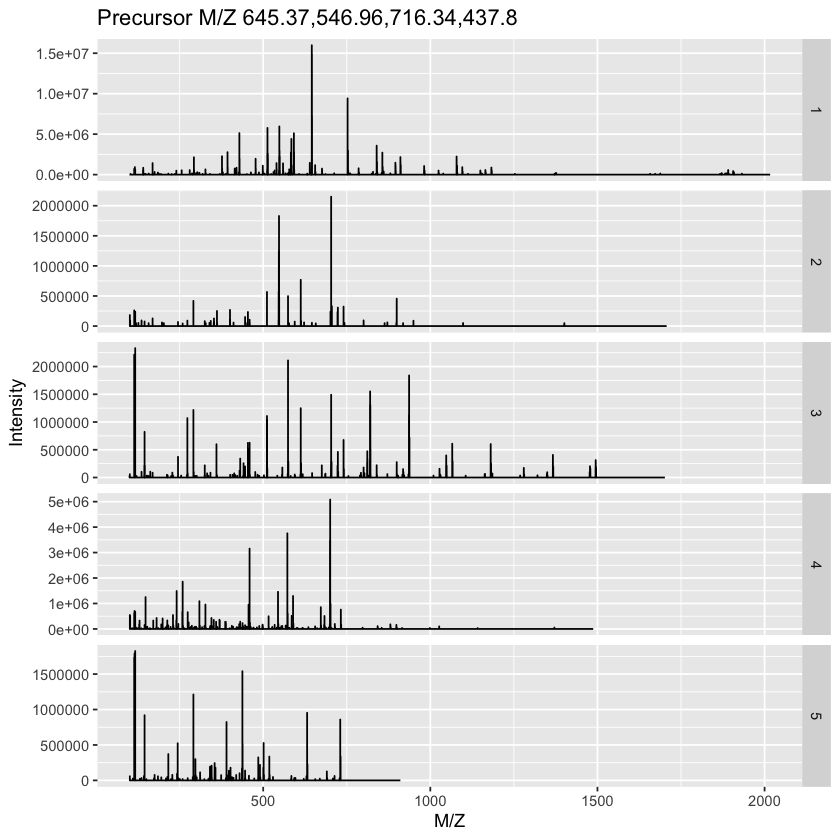

In [18]:
plot(rawdata, full=TRUE)

----
Task 2: Using the “cleaver” package in R for in-silico cleavage of polypeptides, simulate the following cleavages. [2 marks]
	
1.	Cleave the polypeptide “LAAGKVEDSD” using the enzyme “Trypsin”, assuming 100%     efficiency of the enzyme.
2.	Cleave the polypeptide “SITKIKAREILD” using enzyme “Trypsin”, assuming 0 or 1 missing cleavage position.

In [23]:
library("cleaver")

In [24]:
cleave("LAAGKVEDSD", enzym = "trypsin")

$LAAGKVEDSD
[1] "LAAGK" "VEDSD"

In [33]:
cleave("SITKIKAREILD", enzym = "trypsin", missedCleavages = 0:1)
#cleave("SITKIKAREILD", enzym = "trypsin", missedCleavages = 0)
#cleave("SITKIKAREILD", enzym = "trypsin", missedCleavages = 1)

$SITKIKAREILD
[1] "SITK"   "IK"     "AR"     "EILD"   "SITKIK" "IKAR"   "AREILD"

----
Task 3:  Download the following file from  ftp://ftp.pride.ebi.ac.uk/pride/data/archive/2019/10/PXD014124/20190202_QExHFX2_RSLC8_PST_HeLa_10ng_1ulLoop_muPAC_1hr_15k_7.raw

 This data file contains the LC-MS data of a  human NCI-7 Cell Line and will be used for below analysis

1. Convert this “.raw” file into “mzML” format using the “msconvert” or any other tool of your choice.
2. Install and setup “Fragpipe” (https://fragpipe.nesvilab.org/)
3. Using “Fragpipe” run “MsFragger” on this converted dataset with the appropriate proteome database and write an 1 page summary on your interpretation of the output.

[6 marks]

----

In [47]:
install.packages("BiocInstaller")
library("BiocInstaller") 
biocLite("RforProteomics", dependencies = TRUE)
# This ain't working...

Warning message:
“package ‘BiocInstaller’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


ERROR: Error in library("BiocInstaller"): there is no package called ‘BiocInstaller’


----
## References

See also ***[Using R for proteomics data analysis](https://www.bioconductor.org/packages/release/data/experiment/vignettes/RforProteomics/inst/doc/RforProteomics.html)*** by Laurent Gatto, Lisa Breckels, Vlad Petyuk, Thomas Lin Pedersen and Sebastian Gibb